In [2]:
import pandas as  pd
import numpy as np
import cv2
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader , random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score


In [29]:

X = []
y = []
image_ids = []

data_dir = "/Users/ankitsanjyal/Desktop/Projects/Data/Hamm10000"
meta_data = data_dir + '/HAM10000_metadata'
meta_data = pd.read_csv(meta_data,sep=',')

image_dir_1 = data_dir + '/HAM10000_images_part_1'
image_dir_2 = data_dir + '/HAM10000_images_part_2'

dx_mapping = meta_data.set_index('image_id')['dx'].to_dict()

In [30]:

def load_images_from_dir(img_dir, target_size=(256, 256)):
    for img_file in os.listdir(img_dir):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_id = os.path.splitext(img_file)[0]

            if img_id in dx_mapping:
                img_path = os.path.join(img_dir, img_file)
                img = cv2.imread(img_path)

                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, target_size)
                    X.append(img)
                    y.append(dx_mapping[img_id])
                    image_ids.append(img_id)


load_images_from_dir(image_dir_1)
load_images_from_dir(image_dir_2)

X = np.array(X, dtype=np.uint8)     # Much lighter before float conversion
y = np.array(y)
image_ids = np.array(image_ids)

print("X:",X.shape)
print("y:",y.shape)
print("unique diagnoses:",len(np.unique(y)))

X: (10015, 256, 256, 3)
y: (10015,)
unique diagnoses: 7


ISIC_0030749
nv


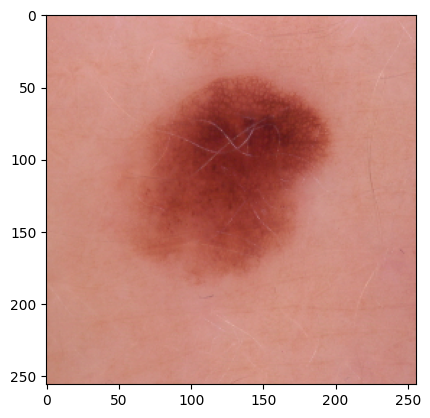

In [35]:
import matplotlib.pyplot as plt
idx = np.random.randint(0,len(X))
plt.imshow(X[idx])
print(image_ids[idx])
print(y[idx])
plt.show()

In [6]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using Device: ",device)

Using Device:  mps


In [36]:
X_flat = X.reshape(X.shape[0],-1).astype(np.float32)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [37]:
from sklearn.model_selection import train_test_split
X_train , X_val,y_train,y_val  = train_test_split(X_flat,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8
X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std 

In [38]:
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Images as tensors
        self.y = torch.tensor(y, dtype=torch.long)    # Labels as tensors

    def __len__(self):
        return len(self.X)  # Return correct dataset size

    def __getitem__(self, idx):
        # Ensuring idx is within bounds
        if idx >= len(self.X) or idx < 0:
            raise IndexError(f"Index {idx} out of bounds.")
        return self.X[idx], self.y[idx]

    
train_dataset = SimpleDataset(X_train, y_train)
val_dataset = SimpleDataset(X_val, y_val)

batch_size = 64
train_loader = DataLoader(train_dataset,batch_size=batch_size , shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=batch_size , shuffle=False)


In [39]:
class LinearSVM(nn.Module):
    def __init__(self,input_dim,num_classes):
        super(LinearSVM,self).__init__()
        self.fc = nn.Linear(input_dim,num_classes)
    def forward(self,x):
        return self.fc(x)

In [40]:
print(f"Training dataset size: {len(X_train)}")
print(f"Training labels size: {len(y_train)}")
print(f"Train loader batch size: {batch_size}")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")


Training dataset size: 8012
Training labels size: 8012
Train loader batch size: 64
X_train shape: (8012, 196608)
X_val shape: (2003, 196608)


In [41]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_encoded))
model = LinearSVM(input_dim,num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=1e-3,weight_decay=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}")



Epoch [1/10], Loss: 7.5354
Epoch [2/10], Loss: 7.5998
Epoch [3/10], Loss: 7.1954
Epoch [4/10], Loss: 6.9920
Epoch [5/10], Loss: 6.7690
Epoch [6/10], Loss: 6.7225
Epoch [7/10], Loss: 6.4688
Epoch [8/10], Loss: 6.0337
Epoch [9/10], Loss: 5.9695
Epoch [10/10], Loss: 6.1034


In [43]:

# Early stopping parameters
patience = 3  # Number of epochs to wait for improvement before stopping
best_val_loss = np.inf  # Initialize with a large number
epochs_without_improvement = 0
best_model_wts = model.state_dict()  # To store the best weights

num_epochs = 50  # Train for more epochs, you can adjust this as needed

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    
    # Evaluate on validation set
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Check if validation loss improved
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        best_model_wts = model.state_dict()  # Save best model weights
    else:
        epochs_without_improvement += 1

    # Early stopping condition
    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Restore the best model weights
model.load_state_dict(best_model_wts)


Epoch [1/50], Train Loss: 6.3979, Val Loss: 10.2119
Epoch [2/50], Train Loss: 5.8907, Val Loss: 7.4961
Epoch [3/50], Train Loss: 5.5523, Val Loss: 7.6400
Epoch [4/50], Train Loss: 5.7470, Val Loss: 8.6572
Epoch [5/50], Train Loss: 5.3706, Val Loss: 6.7855
Epoch [6/50], Train Loss: 5.1852, Val Loss: 14.0622
Epoch [7/50], Train Loss: 5.3104, Val Loss: 6.6355
Epoch [8/50], Train Loss: 5.3729, Val Loss: 21.5658
Epoch [9/50], Train Loss: 5.6057, Val Loss: 6.6834
Epoch [10/50], Train Loss: 5.2857, Val Loss: 8.1694
Early stopping at epoch 10


<All keys matched successfully>


Validation F1 Score (micro): 0.2826
Validation F1 Score (macro): 0.1940

Classification Report:
              precision    recall  f1-score   support

       akiec       0.01      0.14      0.02        65
         bcc       0.22      0.66      0.33       103
         bkl       0.27      0.48      0.35       220
          df       0.00      0.00      0.00        23
         mel       0.30      0.15      0.20       223
          nv       0.82      0.26      0.40      1341
        vasc       0.50      0.04      0.07        28

    accuracy                           0.28      2003
   macro avg       0.30      0.25      0.19      2003
weighted avg       0.63      0.28      0.34      2003



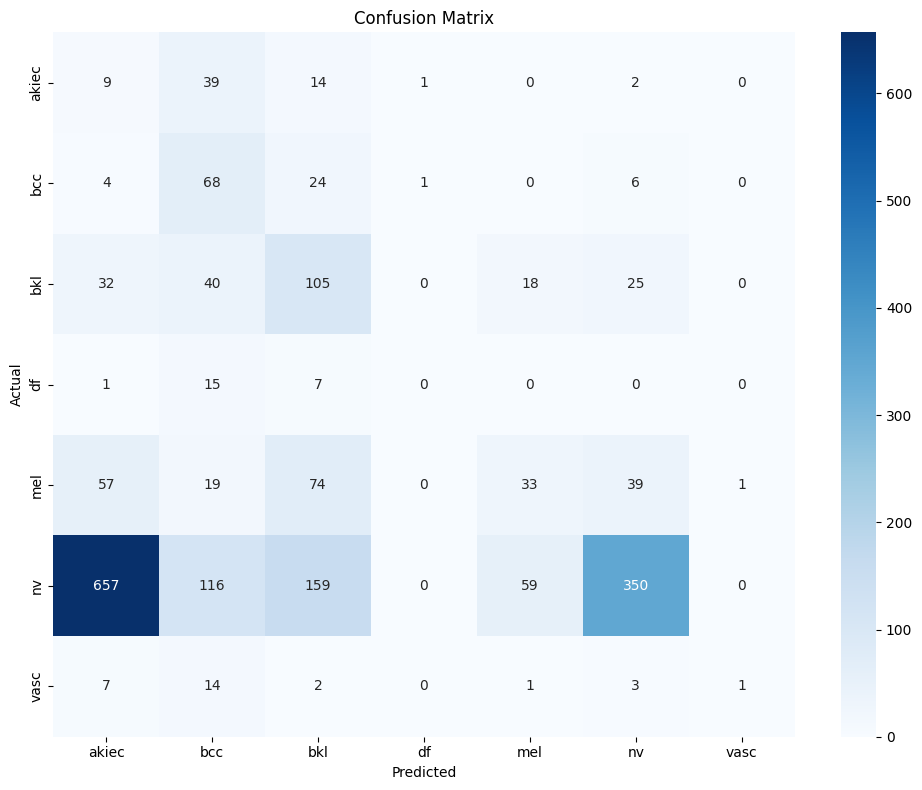

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
class_names = [str(label) for label in np.unique(y)]

def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_batch.numpy())

    f1_micro = f1_score(all_targets, all_preds, average='micro')
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    print(f"\nValidation F1 Score (micro): {f1_micro:.4f}")
    print(f"Validation F1 Score (macro): {f1_macro:.4f}")

    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
evaluate(model, val_loader)
